## PROYECTO MÓDULO 3 - OPTIMIZACIÓN DEL TALENTO

-----------------

In [2]:
# PASO 1: Importamos las librerías necesarias

# Librerías con Pandas::
import pandas as pd # # Para manipular datos en tablas (DataFrames) *
import numpy as np # # Para realizar operaciones numéricas

# Librerías para visualización de datos:
import matplotlib.pyplot as plt # Para crear gráficos personalizados
import seaborn as sns # Para crear gráficos más atractivos y con menos código **

# Configuraciones:
import warnings # Para controlar las advertencias
warnings.filterwarnings('ignore', category = FutureWarning) # Para ignorar las advertencias de tipo FutureWarning
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame *

# FASE I: ANÁLISIS EXPLORATOTIO DE DATOS (EDA)

- Meta: Explorar el dataset

In [3]:
# PASO 1: Cargamos el dataset (archivo .csv) y lo convertimos en un DataFrame de pandas (tabla)

df_hr=pd.read_csv("hr.csv")

df_hr.head() # Mostramos las primeras 5 filas del DataFrame para verificar que se ha cargado correctamente

FileNotFoundError: [Errno 2] No such file or directory: 'hr.csv'

In [ ]:
# PASO 2: Exploramos el dataset para entender su estructura y contenido

df_hr.shape # Muestra las dimensiones de las filas y columnas

(1474, 35)

In [ ]:
df_hr.info() # Muestra la información de nuestro DataFrame: número de filas y columnas + nombre de lascolumnas + valores no nulos + tipos de datos

<class 'pandas.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   str    
 2   BusinessTravel            1357 non-null   str    
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   str    
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   str    
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   str    
 12  HourlyRate                1474 non-null   int64  
 13  JobInvolvement            1474 non-null   int64  
 14  JobLevel           

In [ ]:
df_hr.describe().T # Muestra estadísticas descriptivas de las columnas numéricas: media + desviación típica + mínima + percentiles (mediana) + máxima

,count,mean,std,min,25%,50%,75%,max
Age,1401.0,36.944325,9.105009,18.0,30.00,36.0,43.00,60.0
DailyRate,1474.0,802.702171,403.539530,102.0,465.00,803.0,1157.00,1499.0
DistanceFromHome,1474.0,9.199457,8.104266,1.0,2.00,7.0,14.00,29.0
Education,1474.0,2.911126,1.024267,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1474.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1474.0,1024.471506,602.421193,1.0,488.75,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1474.0,2.723881,1.093280,1.0,2.00,3.0,4.00,4.0
HourlyRate,1474.0,65.887381,20.310444,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1474.0,2.729986,0.712861,1.0,2.00,3.0,3.00,4.0
JobLevel,1474.0,2.063772,1.106055,1.0,1.00,2.0,3.00,5.0


In [ ]:
df_hr.nunique().sort_values(ascending=True) # Indica cuántos valores distintos (únicos) hay en cada columna -> Con esto podemos identificar las columnas redundantes 

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
JobSatisfaction                4
RelationshipSatisfaction       4
StockOptionLevel               4
MaritalStatus                  4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [ ]:
# PASO 3: Observamos los valores nulos

round(df_hr.isna().sum().sort_values(ascending=False)/df_hr.shape[0]*100,2) # Muestra el número de valores nulos que hay por columna en porcentaje y en orden ascendente

StandardHours               11.13
YearsWithCurrManager        10.04
MaritalStatus                8.96
BusinessTravel               7.94
TrainingTimesLastYear        5.97
Age                          4.95
EducationField               3.93
OverTime                     2.99
JobSatisfaction              1.97
Department                   1.97
MonthlyIncome                0.95
Attrition                    0.00
EmployeeNumber               0.00
EmployeeCount                0.00
Gender                       0.00
EnvironmentSatisfaction      0.00
Education                    0.00
DistanceFromHome             0.00
DailyRate                    0.00
JobRole                      0.00
HourlyRate                   0.00
JobInvolvement               0.00
JobLevel                     0.00
Over18                       0.00
PercentSalaryHike            0.00
NumCompaniesWorked           0.00
MonthlyRate                  0.00
RelationshipSatisfaction     0.00
PerformanceRating            0.00
TotalWorkingYe

In [ ]:
#Total General de Nulos 17.3%  de todo el dataframe
round(df_hr.isnull().mean().mean()*100,2)

np.float64(1.74)

In [ ]:
# PASO 4: Revisamos filas duplicadas

df_hr.duplicated().sum() # Muestra cuántos valores hay duplicados -> Copia/s

np.int64(4)

In [ ]:
df_hr[df_hr.duplicated()] # Observamos las 4 filas repetidas

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,sALES eXECUTIVE,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,mANUFACTURING dIRECTOR,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


In [ ]:
df_hr[df_hr.duplicated(keep=False)] # Comprobamos que existen 4 originales y 1 copia por cada original (8). El primero de cada uno es el original y el segundo es la copia -> Nos fijamos en los índices para saber cuál es la copia

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
67,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0
184,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,mANUFACTURING dIRECTOR,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1041,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,sALES eXECUTIVE,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1222,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1470,28.0,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,sALES eXECUTIVE,1.0,Single,8463.0,23490,0,Y,No,18,3,4,NaN,0,6,4.0,3,5,4,1,NaN
1471,53.0,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,mANUFACTURING dIRECTOR,1.0,Divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


In [ ]:
#Eliminamos los duplicados, ya que afectaria la calidad de los datos a futuro
df_hr.drop_duplicates(inplace = True)

In [ ]:
df_hr.duplicated().sum() # Comporbamos los duplicados ahora: 0

np.int64(0)

- ANALISIS DEMOGRÁFICO

In [ ]:
# Observamos la cantidad de Hombre y Mujeres en porcentaje

df_hr['Gender'].value_counts(normalize=True)*100

Gender
Male      60.0
Female    40.0
Name: proportion, dtype: float64

In [ ]:
# Observamos las estadisticas de la Edad redondeada

df_hr['Age'].describe().round(0)

count    1397.0
mean       37.0
std         9.0
min        18.0
25%        30.0
50%        36.0
75%        43.0
max        60.0
Name: Age, dtype: float64

In [ ]:
# Observamos la cantidad de empleados según el Departamento

round(df_hr['Department'].value_counts(normalize=True) * 100,2)

Department
Research & Development    65.16
Sales                     30.46
Human Resources            4.37
Name: proportion, dtype: float64

- ANALISIS DE CARGA LABORAL Y BIENESTAR

In [ ]:
# Observamos el nivel de Deserción General (>15% = alto)
round(df_hr['Attrition'].value_counts(normalize=True)*100,2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

In [ ]:
# Observamos el porcentaje de quienes hacen Horas Extra
round(df_hr['OverTime'].value_counts(normalize=True) * 100,2)

OverTime
No     71.6
Yes    28.4
Name: proportion, dtype: float64

In [ ]:
# Observamos el análisis de Carga Laboral 
round(df_hr['WorkLifeBalance'].value_counts(normalize=True)*100,2) # Posibles resultados: 1 Mala/2 Regular/3 Buena/4 Excelente

WorkLifeBalance
3    60.75
2    23.40
4    10.41
1     5.44
Name: proportion, dtype: float64

# Resumen de Diagnóstico - Fase 1

- **Calidad del Dato:** El dataset presenta una integridad del 82.7%. Se identificaron 4 registros duplicados y errores de formato en JobRole y MaritalStatus que requieren normalización.

- **Perfil Demográfico:** Plantilla madura (mediana 36 años) con predominancia masculina (60%) y alta concentración en el área de I+D (65%).

- **Alerta de Retención:** La tasa de deserción del 16.12% se considera crítica. Se observa una correlación visual preliminar entre la carga laboral (28.4% de horas extra) y los niveles bajos de satisfacción/balance.

- **Otros relevantes:** Tenemos columnas que pensamos que son redundantes:  EmployeeCount (Recuento de empleados), Over18 (Mayor de 18 años), StandardHours (Horas estándar).

# FASE II: TRANSFORMACIÓN DE DATOS


In [5]:
#PASO 1: ELIMINACIÓN DE COLUMNAS REDUNDANTES O IRRELEVANTES

In [ ]:
#Verificamos las columnas que tenemos actualmente
df_hr.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [ ]:
# PASO 1: Eliminamos las columnas que muestran datos redundantes
df_hr.drop(["Over18", "EmployeeCount", "StandardHours"],axis=1,errors="ignore",inplace=True) 

In [ ]:
# Eliminamos columnas sugeridas por el Owner 
df_hr.drop(["HourlyRate", "MonthlyRate", "DailyRate"],axis=1,errors="ignore",inplace=True)  

In [ ]:
#Comprobamos que se han eliminado las columnas correctamente
df_hr.columns  

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [ ]:
#PASO 2: Estandarización de datos

In [ ]:
# Convierte todo el texto del DataFrame a minúsculas
for col in df_hr.select_dtypes(include="str"): 
    df_hr[col]=df_hr[col].str.lower() 

In [ ]:
#Comprobación del formato texto
df_hr.head(2) 

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,yes,travel_rarely,sales,1,2,life sciences,1,2,female,3,2,sales executive,4.0,single,5993.0,8,yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49.0,no,travel_frequently,research & development,8,1,life sciences,2,3,male,2,2,research scientist,2.0,married,5130.0,1,no,23,4,4,1,10,3.0,3,10,7,1,7.0


In [ ]:
#Etiqueta de Marital Status con inconcistencias 
df_hr["MaritalStatus"].unique()

<StringArray>
['single', 'married', 'divorced', nan, 'marreid']
Length: 5, dtype: str

In [ ]:
#Rectificación de texto ('Marreid' --> 'Married')
df_hr["MaritalStatus"] = df_hr["MaritalStatus"].replace("marreid", "married")

In [ ]:
#Comprobación de corrección
df_hr["MaritalStatus"].unique()

<StringArray>
['single', 'married', 'divorced', nan]
Length: 4, dtype: str

In [7]:
#PASO 3: Gestión de valores nulos

In [ ]:
# % de valores nulos por columna 
round(df_hr.isna().sum().sort_values(ascending=False)/df_hr.shape[0]*100,2) 

YearsWithCurrManager        10.00
MaritalStatus                8.98
BusinessTravel               7.96
TrainingTimesLastYear        5.99
Age                          4.97
EducationField               3.95
OverTime                     2.99
Department                   1.97
JobSatisfaction              1.97
MonthlyIncome                0.95
Education                    0.00
DistanceFromHome             0.00
Attrition                    0.00
JobRole                      0.00
JobLevel                     0.00
JobInvolvement               0.00
Gender                       0.00
EnvironmentSatisfaction      0.00
EmployeeNumber               0.00
NumCompaniesWorked           0.00
PercentSalaryHike            0.00
RelationshipSatisfaction     0.00
PerformanceRating            0.00
TotalWorkingYears            0.00
StockOptionLevel             0.00
WorkLifeBalance              0.00
YearsAtCompany               0.00
YearsInCurrentRole           0.00
YearsSinceLastPromotion      0.00
dtype: float64

- Columna: "YearsWithCurrManager"

In [ ]:
#Detección de nulos  147
df_hr["YearsWithCurrManager"].isna().sum()

np.int64(147)

In [ ]:
#Distribución de antigüedad con el jefe actual
df_hr["YearsWithCurrManager"].value_counts().sort_index()

YearsWithCurrManager
0.0     234
1.0      69
2.0     322
3.0     123
4.0      89
5.0      29
6.0      27
7.0     194
8.0      99
9.0      55
10.0     20
11.0     22
12.0     12
13.0     12
14.0      4
15.0      4
16.0      1
17.0      7
Name: count, dtype: int64

In [ ]:
#Filtrado de filas con valores NaN en la columna
df_hr[df_hr["YearsWithCurrManager"].isna()]

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
6,59.0,no,travel_rarely,research & development,3,3,medical,10,3,female,4,1,laboratory technician,1.0,married,2670.0,4,NaN,20,4,1,3,12,3.0,2,1,0,0,NaN
9,36.0,no,travel_rarely,research & development,27,3,NaN,13,3,male,3,2,healthcare representative,3.0,married,5237.0,6,no,13,3,2,2,17,3.0,2,7,7,7,NaN
11,29.0,no,travel_rarely,research & development,15,2,life sciences,15,4,female,2,2,laboratory technician,3.0,NaN,4193.0,0,yes,12,3,4,0,10,3.0,3,9,5,0,NaN
29,46.0,no,travel_rarely,sales,2,4,marketing,38,2,female,3,5,manager,1.0,single,18947.0,3,no,12,3,4,0,22,2.0,2,2,2,2,NaN
33,39.0,yes,travel_rarely,sales,5,3,technical degree,42,4,male,3,2,sales representative,4.0,married,2086.0,3,no,14,3,3,1,19,6.0,4,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1442,29.0,yes,travel_rarely,research & development,1,4,medical,2027,1,male,3,1,research scientist,4.0,married,4787.0,9,yes,14,3,2,3,4,3.0,4,2,2,2,NaN
1445,41.0,no,travel_rarely,research & development,28,4,life sciences,2034,1,female,2,4,manufacturing director,2.0,married,13570.0,0,no,23,4,3,1,21,3.0,3,20,7,0,NaN
1451,38.0,no,travel_rarely,sales,10,2,life sciences,2041,1,female,3,2,sales executive,4.0,married,5343.0,1,no,11,3,3,1,10,1.0,3,10,7,1,NaN
1455,NaN,no,travel_rarely,research & development,2,4,life sciences,2048,3,male,2,1,research scientist,3.0,single,2809.0,2,no,14,3,4,0,8,2.0,3,2,2,2,NaN


In [ ]:
#Analizar la Media,Mediana,Porcentiles,Ect
df_hr["YearsWithCurrManager"].describe() 

count    1323.000000
mean        4.068783
std         3.517918
min         0.000000
25%         2.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: YearsWithCurrManager, dtype: float64

In [ ]:
#Imputación por mediana: Se decidió para mitigar el sesgo provocado por los valores atípicos (outliers)
df_hr["YearsWithCurrManager"] = df_hr["YearsWithCurrManager"].fillna(df_hr["YearsWithCurrManager"].median())

In [ ]:
#comprobación de "0" nulos en columna
df_hr["YearsWithCurrManager"].isna().sum()

np.int64(0)

- Columna: "BusinessTravel"

In [ ]:
#Eliminar #########
#pd.crosstab(df_hr["BusinessTravel"], df_hr["JobRole"], normalize="index").T * 100 # Porcentaje ESTO ES MUY TOP PERO NO LO ENTIENDO DEL TODO QUE LO EXPLIQUE ANITA LUNES!
#moda = pd.crosstab(df_hr["BusinessTravel"], df_hr["JobRole"]).idxmax(axis = 0)
#df_hr["bt_o"] = df_hr["BusinessTravel"]
#df_hr["BusinessTravel"] = df_hr["BusinessTravel"].fillna(df_hr["JobRole"].map(moda))
#df_hr["BusinessTravel"].isna().sum()
#df_hr.drop(["bt_o"], axis = 1, errors = "ignore", inplace = True)
#df_hr.columns

In [ ]:
#Detección de nulos 117
df_hr["BusinessTravel"].isna().sum()

np.int64(117)

In [ ]:
#Analizamos qué porcentaje de cada puesto viaja con qué frecuencia
pd.crosstab(df_hr["BusinessTravel"], df_hr["JobRole"], normalize="index").T * 100

BusinessTravel,non-travel,travel_frequently,travel_rarely
JobRole,,,
healthcare representative,9.352518,8.745247,8.307045
human resources,2.877698,3.422053,3.680336
laboratory technician,19.424460,17.870722,17.875920
manager,7.913669,4.942966,7.676130
manufacturing director,7.194245,10.266160,9.674027
research director,4.316547,4.562738,6.309148
research scientist,19.424460,19.771863,20.084122
sales executive,26.618705,21.673004,21.030494
sales representative,2.877698,8.745247,5.362776


In [ ]:
#Identificamos el valor más frecuente (moda) de viaje para cada puesto específico
moda = pd.crosstab(df_hr["BusinessTravel"], df_hr["JobRole"]).idxmax(axis = 0)
moda

JobRole
healthcare representative     travel_rarely
human resources               travel_rarely
laboratory technician         travel_rarely
manager                       travel_rarely
manufacturing director        travel_rarely
research director             travel_rarely
research scientist            travel_rarely
sales executive               travel_rarely
sales representative          travel_rarely
dtype: str

In [ ]:
#Imputamos con la moda por ser el valor más representativo en datos categóricos, evitando distorsiones y manteniendo coherencia operativa.
df_hr["BusinessTravel"] = df_hr["BusinessTravel"].fillna(df_hr["JobRole"].map(moda))

In [ ]:
# Verificamos que ya no existan nulos 
df_hr["BusinessTravel"].isna().sum()


np.int64(0)

- Columna: "TrainingTimesLastYear"

In [ ]:
#Detección de nulos 88
df_hr["TrainingTimesLastYear"].isna().sum()

np.int64(88)

In [ ]:
# Cálculo del peso relativo de los datos faltantes en la columna con el total de datos del dataset
round(df_hr["TrainingTimesLastYear"].isna().value_counts(normalize=True) * 100, 1)

TrainingTimesLastYear
False    94.0
True      6.0
Name: proportion, dtype: float64

In [ ]:
#Los 88 nulos representan el 6% de nulos globales, la integridad estadística se mantiene; procedemos con imputación por mediana.
df_hr["TrainingTimesLastYear"] = df_hr["TrainingTimesLastYear"].fillna(df_hr["TrainingTimesLastYear"].median())

In [ ]:
#comprobación de "0" nulos en columna
df_hr["TrainingTimesLastYear"].isna().sum()

np.int64(0)

- Columna: "Age"

In [ ]:
#Detección de nulos 73
df_hr["Age"].isna().sum()

np.int64(73)

In [ ]:
#Los 73 nulos representan el 5% de nulos globales
round(df_hr["Age"].isna().value_counts(normalize=True) * 100, 1)

Age
False    95.0
True      5.0
Name: proportion, dtype: float64

In [ ]:
#Obtener Media,Mediana,Porcentiles,Ect
df_hr["Age"].describe() 

count    1397.000000
mean       36.942734
std         9.095617
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

In [ ]:
#Validamos una distribución simétrica con mínima dispersión; elegimos la mediana por su robustez técnica frente a posibles valores 
# atípicos demográficos.
df_hr["Age"] = df_hr["Age"].fillna(df_hr["Age"].median())


In [ ]:
#comprobación de "0" nulos en columna
df_hr["Age"].isna().sum()

np.int64(0)

- Columna: "EducationField"

In [ ]:
#Detección de nulos
df_hr["EducationField"].isna().sum()

np.int64(58)

In [ ]:
#Estandarización de Vacíos """", " ", None
df_hr["EducationField"] = df_hr["EducationField"].replace( ["", " ", None],"Desconocido")  

In [ ]:
#optamos por una Imputación por Categoría Explícita: 'Desconocido'garantizando no crear perfiles académicos inexistentes
df_hr["EducationField"] = df_hr["EducationField"].fillna("Desconocido")

In [ ]:
#comprobación de "0" nulos en columna
df_hr["EducationField"].isna().sum()

np.int64(0)

- Columna: "MaritalStatus"

In [ ]:
#Detección de Nulos 132
df_hr["MaritalStatus"].isna().sum()

np.int64(132)

In [ ]:
# Decidimos imputar con la etiqueta Desconocido para mantener la integridad de los datos y evitar sesgos en el análisis, tambien nos permite observar el comportamiento de este grupo de forma aislada sin forzar conclusiones sobre su situación personal
df_hr["MaritalStatus"] = df_hr["MaritalStatus"].replace(["", " ", None],"Desconocido")    

In [ ]:
#comprobación de "0" nulos en columna
df_hr["MaritalStatus"].isna().sum()

np.int64(0)

- Columna: "OverTime"

In [ ]:
#Detección de Nulos 44
df_hr["OverTime"].isna().sum()

np.int64(44)

In [ ]:
#Identificación del valor más frecuente (No/Moda)
df_hr["OverTime"].describe() 

count     1426
unique       2
top         no
freq      1021
Name: OverTime, dtype: object

In [ ]:
#se optó por una imputación por moda. Dado que la categoría "No" representa aproximadamente el 71.6% de los datos observado
moda_overtime = df_hr["OverTime"].mode()[0]
df_hr["OverTime"] = df_hr["OverTime"].fillna(moda_overtime)
print(f"La moda calculada es: {moda_overtime}")
print(f"Nulos restantes en OverTime: {df_hr['OverTime'].isnull().sum()}")

La moda calculada es: no
Nulos restantes en OverTime: 0


- Columna: "Department"

In [ ]:
#Detección de Nulos 29
df_hr["Department"].isna().sum()

np.int64(29)

In [ ]:
#Obtener Media,Mediana,Porcentiles,Ect
df_hr["Department"].describe()

count                       1441
unique                         3
top       research & development
freq                         939
Name: Department, dtype: object

In [ ]:
# Cálculo de la mediana global ante la homogeneidad de los grupos 
medianas = df_hr.groupby("Department")["YearsWithCurrManager"].median() 
print(medianas)

#me acabo de dar cuenta que en este caso todas las medianas dan lo mismo cno lo que se puede hacer mediana general.

Department
human resources           3.0
research & development    3.0
sales                     3.0
Name: YearsWithCurrManager, dtype: float64


In [ ]:
#Se ha decidido utilizar la mediana agrupada por departamento para capturar la tendencia central de la antigüedad con el manager
df_hr["Department"] = df_hr["Department"].fillna("Desconocido")

In [ ]:
#comprobación de "0" nulos en columna
df_hr["Department"].isna().sum()

np.int64(0)

- Columna: "JobSatisfaction"

In [ ]:
#Detección de Nulos 29
df_hr["JobSatisfaction"].isna().sum()

np.int64(29)

In [ ]:
#Cálculo de la mediana (valor central de la escala)
print(df_hr["JobSatisfaction"].median())

3.0


In [ ]:
#Se aplica la mediana global para completar registros nulos, preservando la escala ordinal original y asegurando la integridad estadística del análisis.
df_hr["JobSatisfaction"] = df_hr["JobSatisfaction"].fillna(df_hr["JobSatisfaction"].median())

In [ ]:
#comprobación de "0" nulos en columna
print(df_hr["JobSatisfaction"].isnull().sum())

0


- Columna: "MonthlyIncome"

In [ ]:
#Detección de Nulos 14
df_hr["MonthlyIncome"].isna().sum()

np.int64(14)

In [ ]:
#vamos a usar la mediana ya que la media esata inflada por salarios altos, imputar media seria usar valores poco realistas
df_hr["MonthlyIncome"].describe() 

count     1456.000000
mean      6498.683379
std       4709.394593
min       1009.000000
25%       2909.000000
50%       4907.000000
75%       8353.500000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [ ]:
#imputar por la mediana
df_hr["MonthlyIncome"] = df_hr["MonthlyIncome"].fillna( df_hr["MonthlyIncome"].median())


In [ ]:
#comprobación de "0" nulos en columna
df_hr["MonthlyIncome"].isna().sum()

np.int64(0)

In [ ]:
# PASO FINAL: Confirmación de limpieza total antes de exportar

df_hr.isnull().sum().sort_values(ascending=False) 

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [ ]:
#Se exporta el dataset limpio garantizando una estructura óptima para análisis y modelado.
df_hr.to_csv("hr_clean.csv",index=False)

# Resumen de Diagnóstico - Fase 2

- **Columnas "EducationField" y "MaritalStatus":** Los valores nulos fueron tratados asignándoles la categoría ‘Desconocido’. Este enfoque es el más adecuado para variables categóricas, ya que evita imputaciones arbitrarias y mantiene la integridad del dataset. Además, el análisis mostró que los empleados con datos desconocidos no presentan diferencias relevantes en variables numéricas, por lo que no constituyen un grupo atípico. Las diferencias observadas se relacionan principalmente con el tipo de puesto o departamento, lo que sugiere que la ausencia de información se debe a procesos administrativos y no a características de los empleados. Por ello, conservar ‘Desconocido’ como categoría es la opción más correcta y transparente.”
- **"Department":** Se utiliza la etiqueta "Desconocido" para evitar el sesgo de información, ya que asignar un departamento al azar alteraría los resultados reales de productividad y rotación. Esta técnica permite preservar la integridad del dataset sin eliminar registros valiosos. Además, ayuda a identificar fallos en la recolección de datos original de la empresa. Al ser un porcentaje bajo de nulos, no afecta las tendencias generales del análisis

# FASE 3: VISUALIZACIÓN DE DATOS

In [ ]:
#VAMOS A SACAR COSAS EN CLARO RELACIONANDO CON LA COLUMNA DE ATRITION!# HE DESCUBIERTO UN TIP!CROSSTAB PERMITE ANALIZAR LA RELACION ENTRE VARIABLES CATEGORICAS MIENTRAS QUE GROUP BY PARA HACER AGRUPACIONES SOBRE LOS DATOS.
tabla_ot=pd.crosstab(df_hr['OverTime'], df_hr['Attrition'], normalize='index') * 100

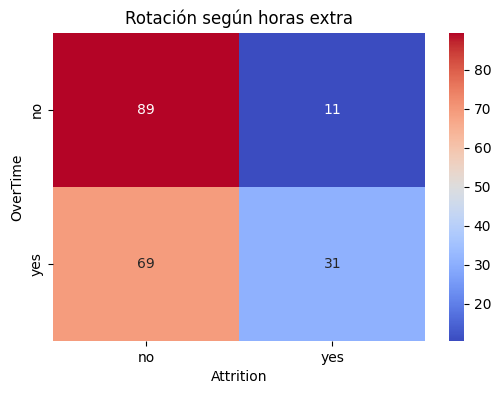

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(tabla_ot, annot=True, cmap='coolwarm')

plt.title("Rotación según horas extra")
plt.show()

el over time esta claramente relacionado con la rotacion sin horas extras solo el 10% se va sin embargo con horas extras el 31 % se va.

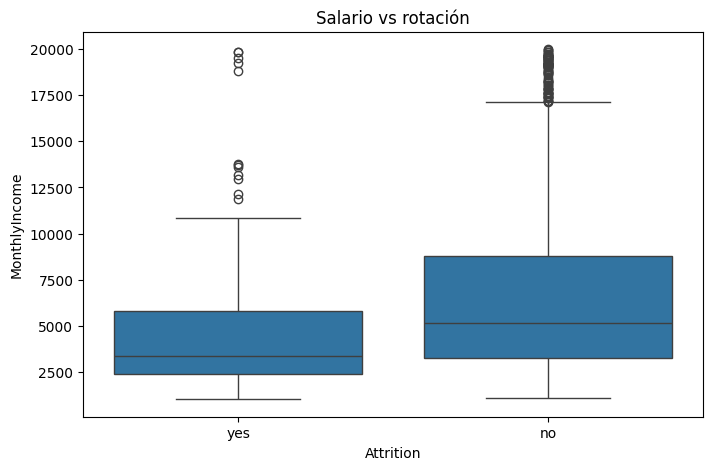

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_hr,
    x='Attrition',
    y='MonthlyIncome'
)

plt.title("Salario vs rotación")
plt.show()

aqui estamos comparando salario vs rotacion y se detecta que los que se van tienen la emdiana mas baja, caja concentrada en salarios mas bajos ganan menos en general , la gente con salarios mas bajos tiende a irse mas.

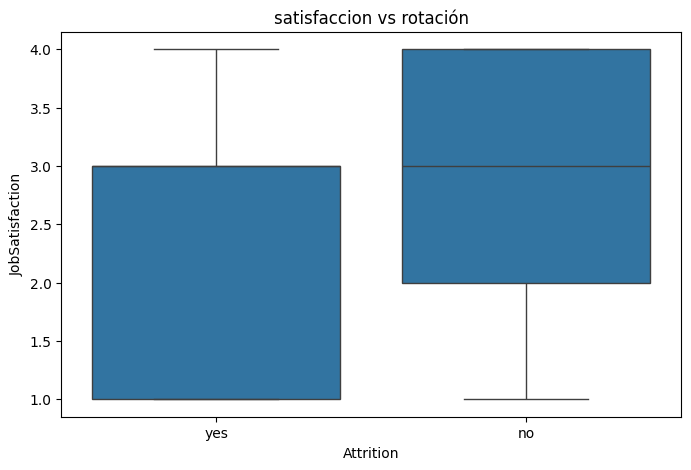

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_hr,
    x='Attrition',
    y='JobSatisfaction'
)

plt.title("satisfaccion vs rotación")
plt.show()

la satisfaccion esta claramente relacionada con la rotacion,en yes hay mucha concentracion en 1 y 2 y en no de 3 a 4! no es casualidad hay un patrono.

In [ ]:
tabla_riesgo = pd.crosstab(
    [df_hr['OverTime'], df_hr['JobSatisfaction']],
    df_hr['Attrition'],
    normalize='index'
) * 100

tabla_riesgo

Attrition                        no        yes
OverTime JobSatisfaction                      
no       1.0              82.125604  17.874396
         2.0              90.291262   9.708738
         3.0              89.880952  10.119048
         4.0              93.354430   6.645570
yes      1.0              64.473684  35.526316
         2.0              62.318841  37.681159
         3.0              65.289256  34.710744
         4.0              78.417266  21.582734

# FASE 4: DISEÑO DE BBDD E INSERCCIÓN DE LOS DATOS